Đang vẽ biểu đồ cặp (pairplot) cho Iris dataset...

Phân tích tương quan giữa các đặc trưng:

Ma trận tương quan:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)             1.0000           -0.1176             0.8718   
sepal width (cm)             -0.1176            1.0000            -0.4284   
petal length (cm)             0.8718           -0.4284             1.0000   
petal width (cm)              0.8179           -0.3661             0.9629   

                   petal width (cm)  
sepal length (cm)            0.8179  
sepal width (cm)            -0.3661  
petal length (cm)            0.9629  
petal width (cm)             1.0000  

Các cặp đặc trưng có tương quan mạnh nhất:
  - petal length (cm) và petal width (cm): 0.9629 (tương quan thuận)
  - sepal length (cm) và petal length (cm): 0.8718 (tương quan thuận)
  - sepal length (cm) và petal width (cm): 0.8179 (tương quan thuận)

Đã lưu biểu đồ vào file 'iris_pairplot.png'


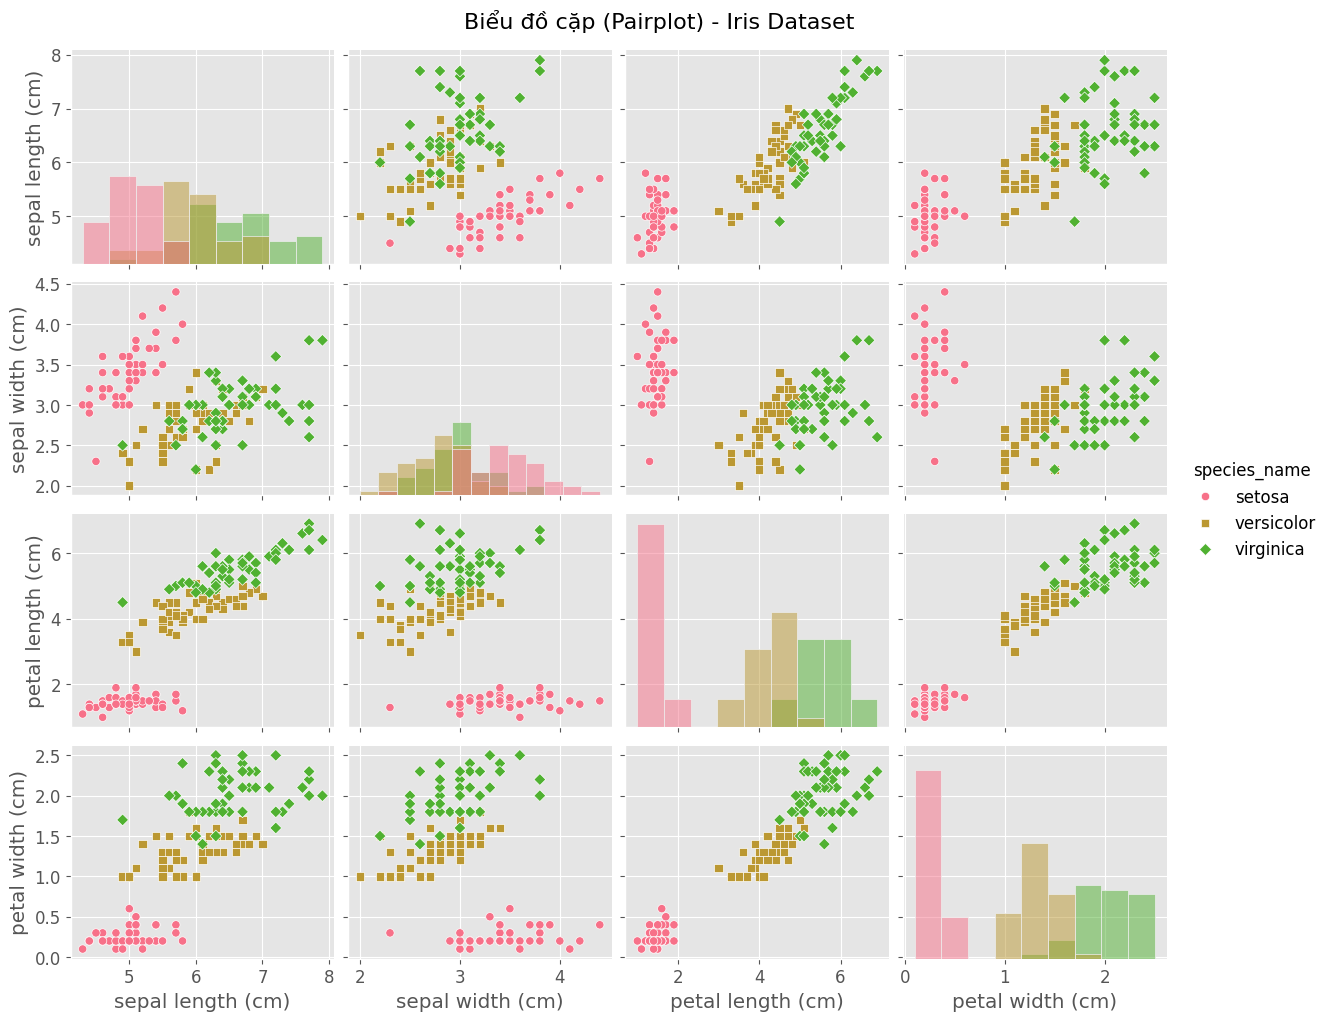

In [2]:
"""
Bài 2.3 - Iris Dataset: Vẽ biểu đồ cặp (sns.pairplot) để thấy mối tương quan giữa các đặc trưng
"""

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Cấu hình hiển thị cho matplotlib
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 12

# Tải dữ liệu Iris từ sklearn
iris = load_iris()

# Tạo DataFrame từ dữ liệu
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Thêm cột nhãn (target) và tên loài
df['species'] = iris.target
species_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_mapping)

# 3. Vẽ biểu đồ cặp (sns.pairplot)
print("Đang vẽ biểu đồ cặp (pairplot) cho Iris dataset...")

# Tạo pairplot với màu sắc phân biệt theo loài
pairplot = sns.pairplot(
    df, 
    hue='species_name', 
    vars=iris.feature_names,
    diag_kind='hist',  # Histogram trên đường chéo
    markers=['o', 's', 'D'],  # Các marker khác nhau cho từng loài
    height=2.5,
    aspect=1.2
)

# Thêm tiêu đề
pairplot.fig.suptitle('Biểu đồ cặp (Pairplot) - Iris Dataset', y=1.02, fontsize=16)

# Thêm chú thích cho tương quan
print("\nPhân tích tương quan giữa các đặc trưng:")

# Tính ma trận tương quan
correlation_matrix = df[iris.feature_names].corr()
print("\nMa trận tương quan:")
print(correlation_matrix.round(4))

# Tìm các cặp tương quan mạnh nhất
print("\nCác cặp đặc trưng có tương quan mạnh nhất:")
corr_pairs = []
for i in range(len(iris.feature_names)):
    for j in range(i+1, len(iris.feature_names)):
        corr_value = correlation_matrix.iloc[i, j]
        corr_pairs.append((iris.feature_names[i], iris.feature_names[j], abs(corr_value), corr_value))

# Sắp xếp theo giá trị tuyệt đối của tương quan
corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in corr_pairs[:3]:  # Hiển thị 3 cặp tương quan mạnh nhất
    print(f"  - {pair[0]} và {pair[1]}: {pair[3]:.4f} ({'tương quan thuận' if pair[3] > 0 else 'tương quan nghịch'})")

# Lưu hình ảnh
plt.savefig('iris_pairplot.png', dpi=300, bbox_inches='tight')
print("\nĐã lưu biểu đồ vào file 'iris_pairplot.png'")

# Hiển thị biểu đồ
plt.show()